# Chest X-Ray Classification — Improved Notebook

**What I changed (high level):**

- Parameterized dataset paths and main hyperparameters
- Set random seeds for reproducibility
- Safer augmentation (no vertical flips)
- Use `image_dataset_from_directory` with `shuffle=False` for test/val
- Optimized `tf.data` pipeline with cache & prefetch
- Binary model with single sigmoid output + `binary_crossentropy`
- Useful metrics (AUC, precision, recall) and callbacks
- Class-weights calculation for imbalanced data
- Training/validation/test evaluation, plots, confusion matrix, ROC
- Grad-CAM helper updated to find last conv layer automatically

You can further toggle using a pretrained backbone (EfficientNet, ResNet) if you want transfer learning.


In [10]:
# Imports and environment checks
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.utils import class_weight

print('TensorFlow version:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPUs: []


In [11]:
# Reproducibility seeds
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [12]:
# Config (change these paths to your data locations)
TRAIN_DIR = 'train'   # directory with subfolders per class
VAL_DIR = 'val'
TEST_DIR = 'test'
BATCH_SIZE = 32
IMAGE_SIZE = 256
CHANNELS = 3
EPOCHS = 5
AUTOTUNE = tf.data.AUTOTUNE

In [13]:
# Create datasets (note: set shuffle=False for val/test)
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print('Classes:', class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 623 files belonging to 2 classes.
Classes: ['NORMAL', 'PNEUMONIA']


In [14]:
# Data pipeline: augmentation, resizing (uses IMAGE_SIZE variable), normalization
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),            # safe for chest X-ray
    layers.RandomRotation(0.05),                # small rotations only
    layers.RandomZoom(0.05),
], name='data_augmentation')

resize_and_rescale = keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
], name='resize_and_rescale')

# Apply pipeline: keep augmentation in model so it's only active during training,
# but ensure dataset uses caching & prefetch for performance.
train_ds = train_ds.map(lambda x, y: (x, y), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [15]:
# Compute class weights (helpful for imbalanced datasets)
labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)
cls_weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: float(w) for i, w in enumerate(cls_weights)}
print('Class weights:', class_weights)

Class weights: {0: 1.9448173005219984, 1: 0.6730322580645162}


In [16]:
# Build a simple but effective CNN. For higher accuracy prefer transfer learning.
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = data_augmentation(inputs)                 # augmentation active during training
x = resize_and_rescale(x)
x = layers.Conv2D(32, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, 3, activation='relu')(x)
x = layers.MaxPooling2D()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # single neuron for binary
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'), keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resize_and_rescale (Sequential)      │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Callbacks: ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, TensorBoard
callbacks = [
    keras.callbacks.ModelCheckpoint('best_model.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    keras.callbacks.TensorBoard(log_dir='logs', histogram_freq=1)
]

In [18]:
# Train the model (using class weights)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.3290 - auc: 0.5231 - loss: 0.6988 - precision: 0.7449 - recall: 0.1285
Epoch 1: val_auc improved from -inf to 0.66406, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 508ms/step - accuracy: 0.3293 - auc: 0.5234 - loss: 0.6988 - precision: 0.7453 - recall: 0.1290 - val_accuracy: 0.6250 - val_auc: 0.6641 - val_loss: 0.6829 - val_precision: 0.5833 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 2/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5058 - auc: 0.6803 - loss: 0.6792 - precision: 0.8520 - recall: 0.4016
Epoch 2: val_auc improved from 0.66406 to 0.70312, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 80s 488ms/step - accuracy: 0.5060 - auc: 0.6805 - loss: 0.6791 - precision: 0.8521 - recall: 0.4019 - val_accuracy: 0.6250 - val_auc: 0.7031 - val_loss: 0.6394 - val_precision: 0.5833 - val_recall: 0.8750 - learning_rate: 1.0000e-04
Epoch 3/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.6691 - auc: 0.8142 - loss: 0.6083 - precision: 0.9161 - recall: 0.6076
Epoch 3: val_auc improved from 0.70312 to 0.75000, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 115s 703ms/step - accuracy: 0.6692 - auc: 0.8142 - loss: 0.6081 - precision: 0.9162 - recall: 0.6078 - val_accuracy: 0.6875 - val_auc: 0.7500 - val_loss: 0.6211 - val_precision: 1.0000 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 4/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.7505 - auc: 0.8485 - loss: 0.5121 - precision: 0.9170 - recall: 0.7262
Epoch 4: val_auc improved from 0.75000 to 0.78906, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 692ms/step - accuracy: 0.7506 - auc: 0.8486 - loss: 0.5120 - precision: 0.9170 - recall: 0.7263 - val_accuracy: 0.6250 - val_auc: 0.7891 - val_loss: 0.6209 - val_precision: 0.7500 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 5/5
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 675ms/step - accuracy: 0.8049 - auc: 0.8882 - loss: 0.4440 - precision: 0.9378 - recall: 0.7866
Epoch 5: val_auc did not improve from 0.78906
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 676ms/step - accuracy: 0.8049 - auc: 0.8882 - loss: 0.4439 - precision: 0.9378 - recall: 0.7866 - val_accuracy: 0.6875 - val_auc: 0.7812 - val_loss: 0.5661 - val_precision: 0.8000 - val_recall: 0.5000 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 4.


Text(0.5, 1.0, 'AUC')

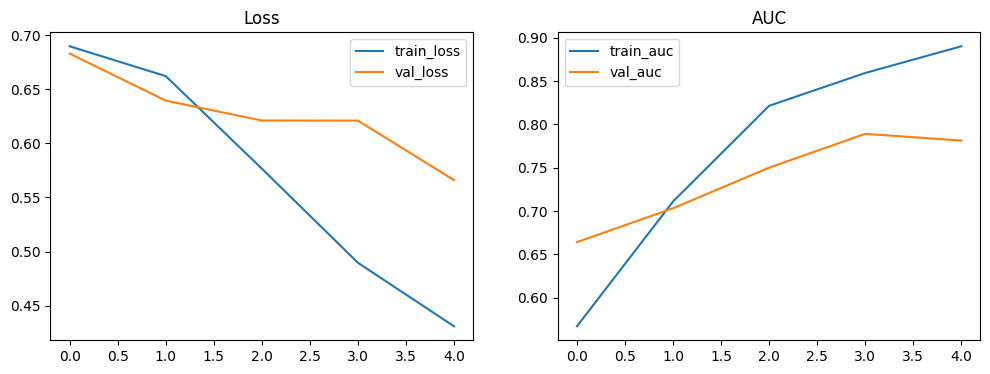

In [19]:
# Plot training curves
import pandas as pd
hist = pd.DataFrame(history.history)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(hist['loss'], label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.legend(); plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(hist['auc'], label='train_auc')
plt.plot(hist['val_auc'], label='val_auc')
plt.legend(); plt.title('AUC')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
              precision    recall  f1-score   support

      NORMAL       0.48      0.99      0.65       233
   PNEUMONIA       0.99      0.36      0.53       390

    accuracy                           0.60       623
  

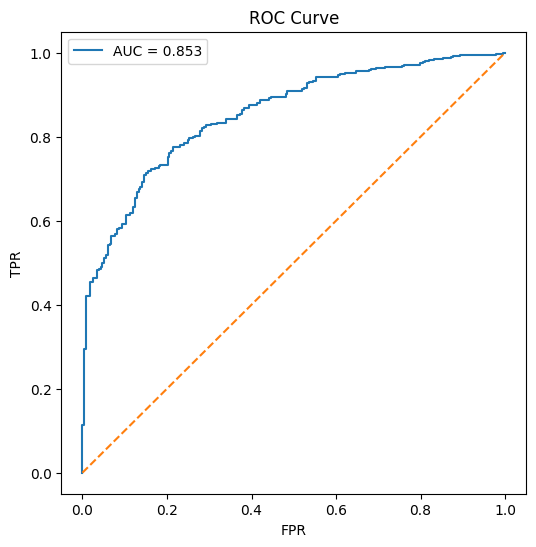

In [20]:
# Evaluate on test set and compute confusion matrix & ROC AUC
# Gather predictions and truths
y_true = []
y_prob = []
for x_batch, y_batch in test_ds:
    probs = model.predict(x_batch)
    y_prob.extend(probs.ravel().tolist())
    y_true.extend(y_batch.numpy().tolist())

y_pred = [1 if p >= 0.5 else 0 for p in y_prob]
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:\n', cm)
roc_auc = roc_auc_score(y_true, y_prob)
print('ROC AUC:', roc_auc)

# Plot ROC
fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend()

In [21]:
# Grad-CAM utilities: find last conv layer automatically
import numpy as np
import matplotlib.cm as cm
def find_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, keras.layers.Conv2D):
            return layer.name
    raise ValueError('No convolutional layer found in the model.')

def make_gradcam_heatmap(img_array, model, last_conv_layer_name=None, pred_index=None):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, 0]  # sigmoid -> single logit/prob
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ tf.expand_dims(pooled_grads, -1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if tf.equal(max_val, 0):
        return np.zeros(shape=heatmap.shape)
    heatmap /= max_val
    return heatmap.numpy()

def display_gradcam(img, heatmap, alpha=0.4):
    img = tf.keras.preprocessing.image.array_to_img(img)
    heatmap = np.uint8(255 * heatmap)
    jet = cm.get_cmap('jet')
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.size[0], img.size[1]))
    superimposed_img = tf.keras.preprocessing.image.array_to_img(
        np.array(img) * (1 - alpha) + np.array(jet_heatmap) * alpha
    )
    plt.imshow(superimposed_img); plt.axis('off'); plt.show()

Notebook CWD: C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray
User home: C:\Users\puska
Found 6 file(s). Showing up to 6 thumbnails and full paths:

[0] C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
[1] C:\Users\puska\OneDrive\Desktop\GitHub Project\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
[2] C:\Users\puska\OneDrive\Desktop\Kaggle\Chest X-Ray\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
[3] C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
[4] C:\Users\puska\OneDrive\Desktop\LungVision\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
[5] C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg


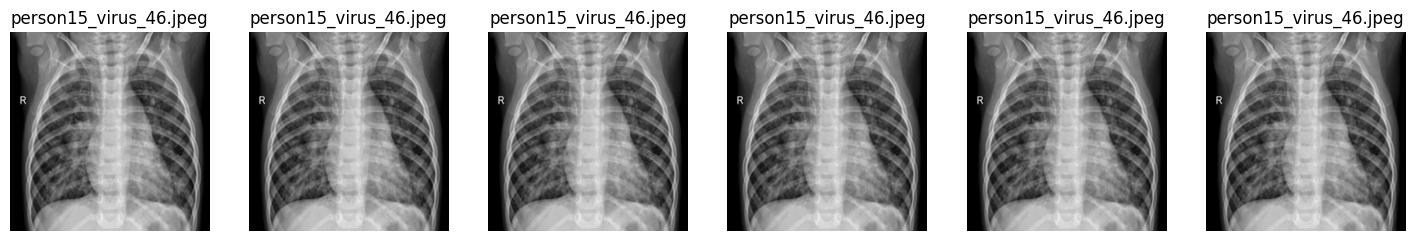


All found (full paths):
C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
C:\Users\puska\OneDrive\Desktop\GitHub Project\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
C:\Users\puska\OneDrive\Desktop\Kaggle\Chest X-Ray\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
C:\Users\puska\OneDrive\Desktop\LungVision\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg
C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg

Use one of the printed full paths (copy exactly) as `img_path` in the Grad-CAM cell.


In [33]:
# Run this to find the exact image file(s) on disk
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# --- CONFIG (change the name substring if needed) ---
name_substring = "person15_virus_46"   # change if you want to search a different base name
max_results = 20                       # how many matches to collect/display
preview_count = 6                      # how many thumbnails to show
# ---------------------------------------------------

print("Notebook CWD:", Path.cwd())
home = Path.home()
print("User home:", home)

# some likely starting locations (add any you know)
candidate_roots = [
    Path.cwd(),
    home,
    Path(r"C:\Users\Puskar - Personal\Desktop"),
    Path(r"C:\Users\Puskar - Personal\Desktop\LungVision"),
    Path(r"C:\Users\Puskar - Personal\Desktop\LungVision\chest_xray"),
    Path(r"C:\Users\Puskar - Personal\Desktop\LungVision\chest_xray\test"),
    Path(r".\test"),
    Path(r"..\test"),
]

found = []
checked = set()
for root in candidate_roots:
    root = root.resolve()
    if not root.exists() or root in checked:
        continue
    checked.add(root)
    try:
        # search recursively for files whose name contains the substring
        for p in root.rglob(f"*{name_substring}*"):
            if p.is_file():
                found.append(p)
                if len(found) >= max_results:
                    break
    except PermissionError:
        # skip folders we can't access
        pass
    if len(found) >= max_results:
        break

# If none found in candidate roots, do a wider search from home (but limit results)
if not found:
    print("No matches in candidate roots — doing a wider search under your home directory (may take a few seconds)...")
    for p in home.rglob(f"*{name_substring}*"):
        if p.is_file():
            found.append(p)
            if len(found) >= max_results:
                break

if not found:
    print("No files found that match the substring. Try changing `name_substring` or adding more candidate_roots.")
else:
    print(f"Found {len(found)} file(s). Showing up to {min(len(found), preview_count)} thumbnails and full paths:\n")
    for i, p in enumerate(found[:preview_count]):
        print(f"[{i}] {p}")
    # show thumbnails
    n = min(preview_count, len(found))
    plt.figure(figsize=(3*n, 3))
    for i, p in enumerate(found[:n]):
        try:
            img = Image.open(p).convert("RGB").resize((256,256))
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(p.name)
            plt.axis("off")
        except Exception as e:
            print("Could not open:", p, "error:", e)
    plt.show()
    # print all found full paths so you can copy one exactly
    print("\nAll found (full paths):")
    for p in found:
        print(str(p))
    print("\nUse one of the printed full paths (copy exactly) as `img_path` in the Grad-CAM cell.")


In [41]:
def display_gradcam(img_path, model, last_conv_layer_name, alpha=0.4):
    import tensorflow as tf
    import numpy as np
    import matplotlib.pyplot as plt
    from tensorflow.keras.preprocessing import image as kimage
    import cv2

    # Auto-detect model input size
    target_size = model.input_shape[1:3]  # (height, width)

    # Load image and resize to model input size
    pil_img = kimage.load_img(img_path, target_size=target_size)
    img_array = kimage.img_to_array(pil_img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Grad-CAM core
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)
    heatmap = heatmap.numpy() if hasattr(heatmap, 'numpy') else heatmap  # ensure NumPy array

    # Load original image (for overlay)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    # Display
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.title(f"Grad-CAM (Class {class_index.numpy()})")
    plt.axis("off")

    plt.show()

    return class_index.numpy(), predictions.numpy()[0]


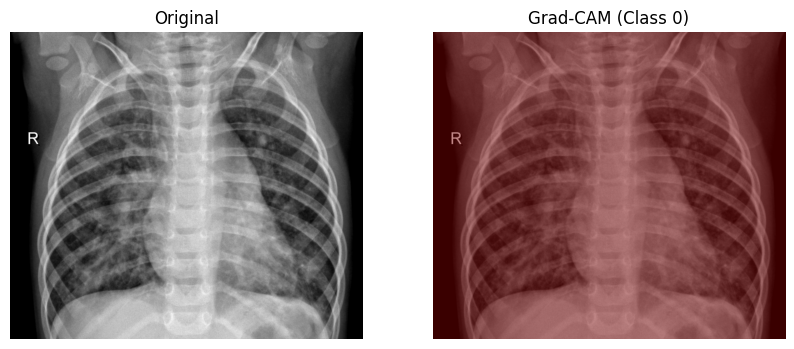

Predicted class index: 0
Prediction probabilities: [0.09139297]


In [42]:
class_idx, preds = display_gradcam(
    img_path="C:/Users/puska/OneDrive/Desktop/LungVision/chest_xray/test/PNEUMONIA/person15_virus_46.jpeg",
    model=model,
    last_conv_layer_name="conv2d_5",
    alpha=0.45
)
print(f"Predicted class index: {class_idx}")
print("Prediction probabilities:", preds)


In [51]:
import numpy as np
import cv2
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap) + 1e-8)

    # ✅ No .numpy() here — it's already NumPy
    return heatmap


In [52]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def overlay_gradcam(img_path, heatmap, alpha=0.5, colormap=cv2.COLORMAP_JET):
    # Load image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize heatmap to match image
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Scale heatmap to 0-255
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap_colored = cv2.applyColorMap(heatmap, colormap)

    # Convert to RGB
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay heatmap on original image
    superimposed_img = cv2.addWeighted(heatmap_colored, alpha, img, 1 - alpha, 0)

    return superimposed_img

In [53]:
import tensorflow as tf

def load_and_preprocess_image(img_path, target_size=(256, 256)):
    # Load image and resize to model's expected input size
    img = tf.keras.utils.load_img(img_path, target_size=target_size)
    img_array = tf.keras.utils.img_to_array(img)
    
    # Add batch dimension
    img_array = tf.expand_dims(img_array, axis=0)
    
    # Optional: normalize if your model was trained on [0, 1] range
    img_array = img_array / 255.0  
    
    return img_array

# Example:
preprocessed_image_array = load_and_preprocess_image(
    r"C:\Users\puska\OneDrive\Desktop\LungVision\chest_xray\test\PNEUMONIA\person15_virus_46.jpeg"
)


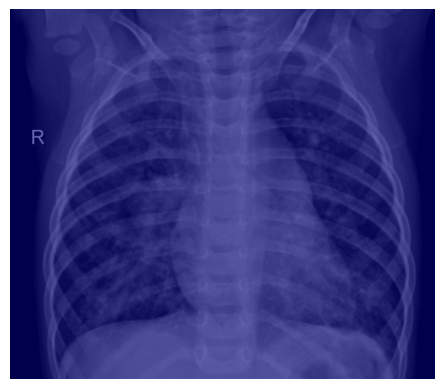

In [54]:
heatmap = make_gradcam_heatmap(
    img_array=preprocessed_image_array,
    model=model,
    last_conv_layer_name="conv2d_5"
)

final_img = overlay_gradcam(
    r"C:/Users/puska/OneDrive/Desktop/LungVision/chest_xray/test/PNEUMONIA/person15_virus_46.jpeg",
    heatmap,
    alpha=0.6  # Higher for stronger heatmap visibility
)

plt.imshow(final_img)
plt.axis("off")
plt.show()

## Save model and next steps

- The best model is saved as `best_model.h5` during training.
- Next steps you might want:
  - Replace the custom CNN with a pretrained backbone (EfficientNetB0, ResNet50) and fine-tune.
  - Add test-time augmentation (TTA) for improved robustness.
  - Integrate inference into a FastAPI endpoint for a backend service.
